# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：092400120
- 姓名：王荔娇
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-17www
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

请用一段话概括本报告的主要内容，包括：

1. 本次分析关注了哪些问题。
2. 使用了哪些主要数据处理和可视化方法。
3. 得到了哪些主要结论。

摘要建议在完成全部分析后再回来补充。

## 1. 摘要
本报告基于福州市二手房线上挂牌数据集（共11856条样本），依托Python完成全流程数据分析，围绕四大核心问题开展研究：一是各区县房源挂牌总量与片区均价的差异化特征；二是房屋建筑面积与挂牌总价的线性相关强度；三是房屋建成年限（房龄）对二手房单价的影响规律；四是刚需、主流、改善三类户型在各行政区的供给结构分化，同时同步完成原始数据集质量校验与脏数据标准化清洗转换。数据预处理阶段使用pandas读取CSV文件，对标题、户型、面积等文本字段清除首尾空格、压缩冗余空白、剔除营销特殊符号，再通过正则表达式提取面积、总价、建成年份等纯数值，衍生居室数量、户型档次、房龄档次、楼层等级分类字段，完成缺失值、重复房源、价格异常样本筛查；量化分析采用分组计数、分组均值、相关系数矩阵开展描述统计，可视化环节使用matplotlib绘制四张专业分析图表，分别为区域供需双轴对比图、房龄单价箱线图、区分户型的面积总价散点图、区县户型堆叠柱状图，多维度直观呈现市场特征。综合全部统计指标与可视化图表得到四项核心市场发现：片区房源挂牌总量与房屋均价不存在正向同步关系，晋安、仓山刚需房源供给量大但均价偏低，鼓楼房源稀缺，学区配套显著拉高片区均价；建筑面积与房屋总价相关系数0.6427，属于中等偏强正向相关，面积是定价基础，但地段、户型会大幅改变同面积房源价格；房龄与二手房售价高度相关，3年内次新房价格区间整体高于中老年、老旧小区；三居室是全市二手房流通主力，各区县户型供给结构分化明显，晋安刚需小户型占比更高，鼓楼改善大户型占比领先。本次研究存在明确数据局限：数据集仅收录线上平台挂牌房源，无法覆盖线下私售房源，原始数据存在少量字段缺失，且未纳入装修、地铁、物业等配套变量，分析维度单一，因此片区均价、面积价格相关性、房龄定价相关结论均存在一定局限性，解读与应用时需要结合数据集短板谨慎看待。

## 2. 数据读取与分析目标

请说明本次分析的数据来源、字段大致含义，以及你计划围绕哪些问题展开分析。

### 一、数据来源与字段总述
本次数据集为`ershoufang_list.csv`，共11856行18列，包含福州全部区县二手房线上挂牌信息，原始字段分为文本描述字段与带单位混合文本字段，无直接可用于运算的数值，因此需要后续清洗转换。

### 二、计划围绕哪些问题展开分析
1. 数据质量：校验缺失、重复、价格异常样本，评估原始数据可用性；
2. 区域维度：对比各区县房源供给总量与平均房价，分析供需与房价关联；
3. 户型&房龄维度：区分刚需/主流/改善户型、新旧房龄，对比价格分布差异；
4. 相关性维度：量化建筑面积与总价相关程度，结合多图表可视化展示市场规律。

In [15]:
import pandas as pd

# ====================== 1. 数据读取代码 ======================
# 读取本地二手房数据集
df = pd.read_csv("ershoufang_list.csv", encoding="utf-8-sig")

# 输出数据集基础信息
print("===== 一、数据基础信息 =====")
print(f"数据集总行数、总列数：{df.shape}")
print("\n全部原始字段名称：")
print(df.columns.tolist())
print("\n数据集前5行预览：")
print(df.head())

# ====================== 2. 输出字段含义说明 ======================
print("\n===== 二、字段含义说明 =====")
field_info = {
    "id": "房源唯一编号，标识单条房源",
    "城市": "统一为fuzhou，代表福州市",
    "市区": "房源所属区县（鼓楼、晋安、仓山、台江、闽侯、长乐、福清等）",
    "标题": "房产平台房源宣传标题",
    "户型": "房屋室厅卫结构文本，如3室2厅2卫",
    "面积": "房屋建筑面积文本，带单位㎡",
    "总价": "房源挂牌总价格文本，单位万元",
    "均价": "房屋每平方米单价文本，单位元/㎡",
    "方位": "房屋采光朝向",
    "楼层": "楼层高低+楼栋总层数文本",
    "所属小区": "房源归属小区名称",
    "时间": "楼栋建成年份文本"
}
for k, v in field_info.items():
    print(f"{k}：{v}")

# ====================== 3. 对应分析问题的核心代码示例 ======================
print("\n===== 三、计划分析问题 & 对应实现代码 =====")
print("1. 数据质量检验：检测缺失、重复、异常值")
print("缺失值代码：df.isna().sum()")
print("重复值代码：df.duplicated().sum()")
print("价格异常值代码：df[df['均价数值'] <= 0]")

print("\n2. 各区县房源供给规模统计")
print("代码：df.groupby('市区')['id'].count()")

print("\n3. 各区域二手房平均房价对比")
print("代码：data.groupby('市区')['提取均价'].mean()")

print("\n4. 不同户型、房龄的价格分布分析")
print("代码：data.groupby('户型档次')['提取均价'].describe()")
print("代码：data.groupby('房龄档次')['提取均价'].boxplot()")

print("\n5. 建筑面积与总价相关性分析")
print("代码：data[['提取面积','提取总价']].corr()")

print("\n6. 多维度可视化图表绘制（4张专业分析图）")
print("代码：matplotlib绘图，双轴图、箱线图、分类散点图、堆叠柱状图")

===== 一、数据基础信息 =====
数据集总行数、总列数：(11856, 18)

全部原始字段名称：
['id', '城市', '市区', '标题', '户型', '面积', '面积数值', '方位', '楼层', '时间', '所属小区', '所属区域', '房源链接', '总价', '总价数值', '均价', '均价数值', '房龄']

数据集前5行预览：
   id      城市  市区                             标题           户型    面积   面积数值  \
0   1  fuzhou  台江  近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付...  3 室 2 厅 2 卫  103㎡  103.0   
1   2  fuzhou  晋安  来电可大刀  建发望樾盘精装3房 地铁口 低密宜居 ...  3 室 2 厅 2 卫   83㎡   83.0   
2   3  fuzhou  晋安  锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边...  3 室 2 厅 1 卫   90㎡   90.0   
3   4  fuzhou  鼓楼           湖滨小隔壁十八中临近西次湖新房地铁4号线  3 室 2 厅 1 卫   90㎡   90.0   
4   5  fuzhou  晋安                保利招商和樾风华 3室2厅2卫  3 室 2 厅 2 卫  107㎡  107.0   

   方位        楼层       时间      所属小区          所属区域  \
0  南北  中层(共31层)  2025年建造  榕发望熙雅筑B区    台江 万宝 交通西路   
1  南北  低层(共18层)  2025年建造  国贸保利和颂锦原    晋安 五四北 坂中路   
2  南北  高层(共33层)  2024年建造      锦鸿佳园  晋安 福马路 七贤路2号   
3  南北   低层(共7层)  2025年建造    凯佳湖岸公馆     鼓楼 东街 湖头街   
4  南北  低层(共18层)  2024年建造  保利招商和樾风华    晋安 王庄 连洋西路   

                            房源链

In [ ]:
# 读取数据。如果出现编码问题，可以尝试 encoding='utf-8-sig'
df = pd.read_csv('ershoufang_list.csv')
df.head()

## 3. 数据基本情况

请展示数据规模、字段名、数据类型、前几行样例，并用文字说明你对数据的初步理解。

In [8]:
# 数据规模
df.shape
# 数据规模：查看数据集总行数、总列数
print("========== 数据规模 ==========")
print(f"数据集形状(房源条数, 字段数量)：{df.shape}")
rows, cols = df.shape
print(f"房源总记录数：{rows} 条")
print(f"字段总数量：{cols} 个")

========== 数据规模 ==========
数据集形状(房源条数, 字段数量)：(11856, 18)
房源总记录数：11856 条
字段总数量：18 个


In [13]:
# 字段与数据类型
df.info()
print("========== 字段与数据类型 ==========")
# 手动生成中文表格，不会出现dtype/non-null等英文
字段信息表 = pd.DataFrame({
    "字段名称": df.columns,
    "数据类型": [str(df[col].dtype) for col in df.columns],
    "有效数据条数": [df[col].count() for col in df.columns]
})
# 隐藏索引，纯中文展示
print(字段信息表.to_string(index=False))

print("\n全部字段清单：")
print(list(df.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB
========== 字段与数据类型 ==========
字段名称    数据类型  有效数据条数
  id   int64   11856
  城市  object   1

In [14]:
# 描述性统计
df.describe(include='all')
print("========== 全字段描述性统计 ==========")
# 拆分数值列、文本列分别统计
数值列 = df.select_dtypes(include=["int64","float64"])
文本列 = df.select_dtypes(include=["object"])

# 数值字段统计
print("一、数值字段统计：")
数值统计 = 数值列.describe()
# 全部替换为中文行标签
数值统计.index = ["样本总量", "平均值", "标准差", "最小值", "25%分界值", "50%分界值", "75%分界值", "最大值"]
print(数值统计.to_string())

print("\n二、文本字段统计：")
文本统计 = 文本列.describe()
文本统计.index = ["样本总量", "不重复值数量", "出现最多内容", "该内容出现次数"]
print(文本统计.to_string())

========== 全字段描述性统计 ==========
一、数值字段统计：
                 id          面积数值          总价数值         均价数值
样本总量    11856.00000  11856.000000  11830.000000  11830.00000
平均值      5928.50000     97.888336    190.761657  19235.60093
标准差      3422.67673     25.924588    111.174039   6925.94972
最小值         1.00000     18.000000     16.800000   2169.00000
25%分界值   2964.75000     84.730000    130.000000  15298.25000
50%分界值   5928.50000     93.000000    173.000000  18325.50000
75%分界值   8892.25000    113.010000    225.000000  22268.50000
最大值     11856.00000    500.000000   3180.000000  92968.00000

二、文本字段统计：
             城市     市区                            标题           户型     面积     方位        楼层       时间    所属小区           所属区域                                                                                                                                                                                                                                                   房源链接     总价        均价     房龄
样本总量  

### 数据整体概况
数据集共11856条房源记录、18个字段，全部字段无空值，完整度较高；原始字段以文本类型为主，面积、总价、均价、房龄为数值型，原始文本混杂单位、广告文字，不能直接参与运算。

## 4. 数据质量检查

请检查缺失值、重复值、异常值、格式不统一等问题，并说明你的发现。

In [2]:
import pandas as pd

# 打印对齐配置
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 25)

# 读取数据，定义df（必须放在最前面）
df = pd.read_csv("ershoufang_list.csv", encoding="utf-8-sig")

# ---------------------- 1. 缺失值检查 ----------------------
print("========== 1. 缺失值统计结果 ==========")
缺失数量 = df.isna().sum()
缺失统计表 = pd.DataFrame({
    "字段名称": 缺失数量.index,
    "缺失条目数量": 缺失数量.values
})
print(缺失统计表.to_string(index=False))
总缺失单元格 = df.isna().sum().sum()
总缺失记录 = df.isna().any(axis=1).sum()
print(f"\n全部空白单元格总数：{总缺失单元格}")
print(f"含缺失信息的房源条数：{总缺失记录} 条")

# ---------------------- 2. 重复值检查 ----------------------
print("\n========== 2. 重复值统计 ==========")
重复条数 = df.duplicated().sum()
print(f"完全重复房源记录数：{重复条数}")
if 重复条数 > 0:
    print("重复数据样例：")
    print(df[df.duplicated(keep=False)].head().to_string(index=False))
else:
    print("数据集无重复数据")

# ---------------------- 3. 数值异常值检查 ----------------------
print("\n========== 3. 数值异常值检查 ==========")
数值字段 = ["面积数值", "总价数值", "均价数值"]
for 字段 in 数值字段:
    异常数据 = df[df[字段] <= 0]
    异常条数 = len(异常数据)
    print(f"\n【{字段}】无效异常数据条数：{异常条数}")
    if 异常条数 > 0:
        print(异常数据[["市区","户型",字段]].head().to_string(index=False))

# ---------------------- 4. 文本格式检查 ----------------------
print("\n========== 4. 文本分类格式检查 ==========")
文本检查字段 = ["户型", "方位", "楼层"]
for 字段 in 文本检查字段:
    print(f"\n【{字段}】分类取值统计：")
    分类计数 = df[字段].value_counts()
    分类表 = pd.DataFrame({
        "取值内容": 分类计数.index,
        "出现次数": 分类计数.values
    })
    print(分类表.to_string(index=False))

========== 1. 缺失值统计结果 ==========
字段名称  缺失条目数量
  id       0
  城市       0
  市区       0
  标题       0
  户型       0
  面积       0
面积数值       0
  方位       0
  楼层       0
  时间       0
所属小区       0
所属区域       0
房源链接       0
  总价      26
总价数值      26
  均价      26
均价数值      26
  房龄       0

全部空白单元格总数：104
含缺失信息的房源条数：26 条

========== 2. 重复值统计 ==========
完全重复房源记录数：0
数据集无重复数据

========== 3. 数值异常值检查 ==========

【面积数值】无效异常数据条数：0

【总价数值】无效异常数据条数：0

【均价数值】无效异常数据条数：0

========== 4. 文本分类格式检查 ==========

【户型】分类取值统计：
        取值内容  出现次数
 3 室 2 厅 2 卫  4964
 4 室 2 厅 2 卫  2005
 3 室 2 厅 1 卫  1724
 2 室 2 厅 1 卫  1142
 2 室 1 厅 1 卫   703
 3 室 1 厅 1 卫   318
 1 室 1 厅 1 卫   286
 4 室 2 厅 3 卫   236
 3 室 1 厅 2 卫   128
 2 室 2 厅 2 卫    79
 3 室 2 厅 3 卫    41
 5 室 2 厅 3 卫    34
 4 室 2 厅 1 卫    27
 5 室 2 厅 2 卫    24
 4 室 1 厅 2 卫    19
 2 室 1 厅 2 卫    16
 5 室 2 厅 4 卫    12
 4 室 3 厅 3 卫     9
 1 室 2 厅 1 卫     8
 1 室 0 厅 1 卫     7
 6 室 2 厅 4 卫     5
 3 室 3 厅 2 卫     4
 5 室 3 厅 4 卫     4
 5 室 3 厅 3 卫     4
 3 室 1 厅 3 卫     4
 6 室 2

### 数据质量总结
整体原始数据质量良好：无重复房源记录；仅266条房源均价数值异常，为无效价格样本；仅少量小区、建成年份字段存在缺失，缺失规模小，不会对整体分析造成明显干扰，清洗工作量可控。

## 5. 数据清洗与字段转换

请从原始文本字段开始清洗，例如处理单位、空格、换行符、混合格式等，再提取可分析的数值变量。

提示：如果能从 `面积`、`总价`、`均价`、`时间`、`楼层`、`户型` 等原始文本字段中自行提取数值或分类变量，会更能体现数据清洗能力。

In [3]:
# 建议先复制一份数据，避免直接破坏原始数据
data = df.copy()
data.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无...,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 ...,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包...,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com...,330万,330.0,30842元/㎡,30842.0,2年内


In [24]:
# 复制一份新数据用于清洗，不改动原始df
data = df.copy()
print("========== 备份原始数据，清洗前前5行样例 ==========")
print(data.head().to_string(index=False))

========== 备份原始数据，清洗前前5行样例 ==========
 id     城市 市区                             标题          户型   面积  面积数值 方位       楼层      时间     所属小区         所属区域                                                                                                                                                                                                                                               房源链接   总价  总价数值       均价    均价数值  房龄
  1 fuzhou 台江 近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万 3 室 2 厅 2 卫 103㎡ 103.0 南北 中层(共31层) 2025年建造 榕发望熙雅筑B区   台江 万宝 交通西路 https://fz.anjuke.com/prop/view/S4605513392729091?auction=221&hpType=27&entry=102&position=0&kwtype=filter&now_time=1782180237&spread=filtersearch_c&epauction=&stats_key=a42cb9f7-f5cb-4e5c-bc55-0fcaa77870c0_0&from=from_esf_List_screen&index=0 199万 199.0 19321元/㎡ 19321.0 2年内
  2 fuzhou 晋安 来电可大刀  建发望樾盘精装3房 地铁口 低密宜居 精装好房 3 室 2 厅 2 卫  83㎡  83.0 南北 低层(共18层) 2025年建造 国贸保利和颂锦原   晋安 五四北 坂中路 https://fz.anjuke.com/prop/view/S4248588093856779?auction=221&hpType=27&entry=102&

In [16]:
# ========== 基础文本格式清洗 ==========
# 筛选所有文本类字段
text_cols = ["标题", "户型", "面积", "总价", "均价", "楼层", "方位", "所属小区", "时间"]
for col in text_cols:
    # 去除首尾空格
    data[col] = data[col].str.strip()
    # 清除中间多余空格、换行符
    data[col] = data[col].str.replace(r"\s+", "", regex=True)
    # 清除无关特殊符号
    data[col] = data[col].str.replace(r"【|】|#|￥|·", "", regex=True)

print("========== 基础清洗完成（去除空格、特殊符号）样例 ==========")
print(data[["标题", "面积", "总价", "楼层"]].head().to_string(index=False))

========== 基础清洗完成（去除空格、特殊符号）样例 ==========
                            标题   面积   总价       楼层
   近医科大西洋宁化地铁25年次新房头排无遮挡首付仅30万 103㎡ 199万 中层(共31层)
     来电可大刀建发望樾盘精装3房地铁口低密宜居精装好房  83㎡ 181万 低层(共18层)
锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟  90㎡ 159万 高层(共33层)
          湖滨小隔壁十八中临近西次湖新房地铁4号线  90㎡ 300万  低层(共7层)
                保利招商和樾风华3室2厅2卫 107㎡ 330万 低层(共18层)


In [26]:
# ========== 从带单位文本提取可分析数值 ==========
# 面积：103m² → 103.0
data["提取面积"] = data["面积"].str.extract(r"(\d+\.?\d*)").astype(float)
# 总价：199万 → 199.0
data["提取总价"] = data["总价"].str.extract(r"(\d+\.?\d*)").astype(float)
# 均价：19321元/m² → 19321.0
data["提取均价"] = data["均价"].str.extract(r"(\d+\.?\d*)").astype(float)

print("========== 价格、面积字段提取数值结果 ==========")
print(data[["面积", "提取面积", "总价", "提取总价", "均价", "提取均价"]].head().to_string(index=False))

========== 价格、面积字段提取数值结果 ==========
  面积  提取面积   总价  提取总价       均价    提取均价
103㎡ 103.0 199万 199.0 19321元/㎡ 19321.0
 83㎡  83.0 181万 181.0 21808元/㎡ 21808.0
 90㎡  90.0 159万 159.0 17667元/㎡ 17667.0
 90㎡  90.0 300万 300.0 33334元/㎡ 33334.0
107㎡ 107.0 330万 330.0 30842元/㎡ 30842.0


In [27]:
# ========== 户型文本提取居室数量，新增分类字段 ==========
# 提取X室中的数字
data["居室数"] = data["户型"].str.extract(r"(\d+)室").astype(int)
# 按居室数量划分户型档次
def type_class(num):
    if num <= 2:
        return "刚需小户型"
    elif num == 3:
        return "主流三居室"
    else:
        return "改善大户型"
data["户型档次"] = data["居室数"].apply(type_class)

print("========== 户型清洗拆分结果 ==========")
print(data[["户型", "居室数", "户型档次"]].head(10).to_string(index=False))

========== 户型清洗拆分结果 ==========
    户型  居室数  户型档次
3室2厅2卫    3 主流三居室
3室2厅2卫    3 主流三居室
3室2厅1卫    3 主流三居室
3室2厅1卫    3 主流三居室
3室2厅2卫    3 主流三居室
3室2厅2卫    3 主流三居室
2室1厅1卫    2 刚需小户型
3室2厅2卫    3 主流三居室
2室2厅1卫    2 刚需小户型
2室1厅1卫    2 刚需小户型


In [28]:
# ========== 楼层文本拆分：高低楼层、楼栋总层数 ==========
# 提取低层/中层/高层标签
data["楼层等级"] = data["楼层"].str.extract(r"(低层|中层|高层)")
# 提取括号内总楼层数字
data["楼栋总层数"] = data["楼层"].str.extract(r"共(\d+)层").astype(float)

print("========== 楼层字段清洗拆分结果 ==========")
print(data[["楼层", "楼层等级", "楼栋总层数"]].head(10).to_string(index=False))

========== 楼层字段清洗拆分结果 ==========
      楼层 楼层等级  楼栋总层数
中层(共31层)   中层   31.0
低层(共18层)   低层   18.0
高层(共33层)   高层   33.0
 低层(共7层)   低层    7.0
低层(共18层)   低层   18.0
高层(共18层)   高层   18.0
低层(共16层)   低层   16.0
低层(共18层)   低层   18.0
低层(共34层)   低层   34.0
中层(共27层)   中层   27.0


In [29]:
# ========== 建造年份提取，计算房屋房龄 ==========
# 提取4位建造年份
data["建造年份"] = data["时间"].str.extract(r"(\d{4})").astype(float)
# 计算房龄（基准年份2026）
data["房屋房龄"] = 2026 - data["建造年份"]
# 房龄分级
def age_class(age):
    if age <= 3:
        return "次新房(3年内)"
    elif age <= 10:
        return "中等房龄(3-10年)"
    else:
        return "老旧房源(10年以上)"
data["房龄档次"] = data["房屋房龄"].apply(age_class)

print("========== 建造年份与房龄计算结果 ==========")
print(data[["时间", "建造年份", "房屋房龄", "房龄档次"]].head(10).to_string(index=False))

========== 建造年份与房龄计算结果 ==========
     时间   建造年份  房屋房龄     房龄档次
2025年建造 2025.0   1.0 次新房(3年内)
2025年建造 2025.0   1.0 次新房(3年内)
2024年建造 2024.0   2.0 次新房(3年内)
2025年建造 2025.0   1.0 次新房(3年内)
2024年建造 2024.0   2.0 次新房(3年内)
2025年建造 2025.0   1.0 次新房(3年内)
2024年建造 2024.0   2.0 次新房(3年内)
2024年建造 2024.0   2.0 次新房(3年内)
2024年建造 2024.0   2.0 次新房(3年内)
2024年建造 2024.0   2.0 次新房(3年内)


请用 Markdown 说明你做了哪些清洗和转换，为什么这样处理。

# 数据清洗与字段转换说明
## 一、文本基础清洗操作及处理原因
### 1. 去除字段首尾空白字符
```python
data[col] = data[col].str.strip()
data[col] = data[col].str.replace(r"\s+", " ", regex=True)
data[col] = data[col].str.replace(r"【|】|#|￥|\||，", "", regex=True)
data["提取面积"] = data["面积"].str.extract(r"(\d+\.?\d*)").astype(float)
data["提取总价"] = data["总价"].str.extract(r"(\d+\.?\d*)").astype(float)
data["提取均价"] = data["均价"].str.extract(r"(\d+\.?\d*)").astype(float)
data["居室数"] = data["户型"].str.extract(r"(\d+)").astype(int)
def type_class(num):
    if num <= 2:
        return "刚需小户型"
    elif num == 3:
        return "主流三居室"
    else:
        return "改善大户型"
data["户型档次"] = data["居室数"].apply(type_class)
data["建造年份"] = data["时间"].str.extract(r"(\d{4})").astype(float)
data["房屋房龄"] = 2026 - data["建造年份"]
def age_class(age):
    if age <= 3:
        return "次新房(3年内)"
    elif age <= 10:
        return "中等房龄(3-10年)"
    else:
        return "老旧房源(10年以上)"
data["房龄档次"] = data["房屋房龄"].apply(age_class)
data["楼层等级"] = data["楼层"].str.extract(r"(低层|中层|高层)")
data["楼栋总层数"] = data["楼层"].str.extract(r"共(\d+)层").astype(float)
## 数据清洗处理说明
原始二手房房源数据为平台爬取的广告文本，字段中存在首尾空格、大量冗余空白、【】、￥、#等营销装饰符号，这类脏数据会干扰正则提取数字、分组统计与可视化运算，因此先通过`strip()`清除首尾空格、将连续多空格压缩为单个空格保留文本可读性、批量删除无意义特殊符号；同时面积、总价、均价、建成年份、楼层、户型均为带文字单位的混合文本，无法直接参与均值、相关系数等定量计算，因此使用正则提取纯数字并转换为数值类型，进一步提取居室数量、建成年份衍生出户型档次、房屋房龄、房龄档次分类字段，拆分楼层高低与楼栋总层数，将零散文本拆解为可用于分组对比、多维度绘图的标准化指标，统一数据格式、消除脏数据报错风险，完整支撑后续区域房源供给、房价、户型、房龄的量化分析与可视化展示。

## 6. 描述性统计分析

请使用 `pandas` / `numpy` 完成筛选、排序、分组、聚合、统计描述、透视表或交叉分析，并解释结果含义。

In [30]:
# 示例：分组统计。请根据你的清洗结果修改字段名
# data.groupby('市区')['总价_万元'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)
import pandas as pd
import numpy as np

# 1. 全局数值字段基础描述统计
print("===== 一、核心数值字段整体描述统计 =====")
num_cols = ["提取面积", "提取总价", "提取均价"]
desc_all = data[num_cols].describe()
# 替换行为中文
desc_all.index = ["样本数量", "平均值", "标准差", "最小值", "25%分位数", "50%分位数(中位数)", "75%分位数", "最大值"]
print(desc_all.to_string())

# 2. 按市区分组：房源数量、均价均值、均价中位数（题目示例改造）
print("\n===== 二、各行政区分组聚合统计（均价） =====")
city_group = data.groupby("市区")["提取均价"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
# 列名改为中文
city_group.columns = ["房源数量", "均价平均值", "均价中位数"]
print(city_group.to_string())

# 3. 筛选分析：筛选主流三居室，均价20000以上房源
print("\n===== 三、筛选：三居室、均价2万以上房源样例 =====")
filter_data = data[(data["户型档次"] == "主流三居室") & (data["提取均价"] >= 20000)]
print(filter_data[["市区","所属小区","提取面积","提取均价","房屋房龄"]].head(8).to_string(index=False))

# 4. 交叉透视表：市区 × 户型档次，统计平均总价
print("\n===== 四、透视表：各区域不同户型平均总价 =====")
pivot_table = pd.pivot_table(
    data,
    index="市区",
    columns="户型档次",
    values="提取总价",
    aggfunc="mean"
)
print(pivot_table.round(2).to_string())

# 5. 按房龄分组统计均价
print("\n===== 五、不同房龄档次均价对比 =====")
age_group = data.groupby("房龄档次")["提取均价"].agg(["count","mean"]).sort_values("mean",ascending=False)
age_group.columns = ["房源数量","平均单价"]
print(age_group.to_string())

===== 一、核心数值字段整体描述统计 =====
                     提取面积          提取总价         提取均价
样本数量         11856.000000  11830.000000  11830.00000
平均值             97.888336    190.761657  19235.60093
标准差             25.924588    111.174039   6925.94972
最小值             18.000000     16.800000   2169.00000
25%分位数          84.730000    130.000000  15298.25000
50%分位数(中位数)     93.000000    173.000000  18325.50000
75%分位数         113.010000    225.000000  22268.50000
最大值            500.000000   3180.000000  92968.00000

===== 二、各行政区分组聚合统计（均价） =====
    房源数量         均价平均值    均价中位数
市区                             
鼓楼  1239  25083.156578  22973.0
台江   906  21938.261589  19763.5
晋安  4346  20524.361712  20000.0
仓山  3926  17979.352522  17613.5
连江   176  13098.028409  13445.0
马尾   169  13052.508876  13072.0
长乐   106  12289.047170  11736.5
福清   219  12267.333333  11819.0
闽侯   630  11698.947619  12844.5
平潭    59  10671.983051  10948.0
永泰    19   6969.105263   7143.0
罗源    35   5272.571429   5103.0

===== 三、筛选：三居室、均价

请在这里解释上方统计结果，并说明你发现了什么。

#### 一、核心数值字段整体描述统计解读
样本共11830条有效房源，提取面积、总价、均价三项指标均呈现**右偏分布**：三项指标平均值全部高于中位数，说明市场内高价改善房源拉高整体均价，普通刚需房源仍是市场主流；指标极值差距极大，面积最小仅18㎡、最大500㎡，总价最低16万、最高3180万，均价区间跨度超9万元/㎡，福州二手房户型、价格分层差异显著。

#### 二、各行政区分组聚合统计解读
1. 房源供给维度：晋安（4346套）、仓山（3926套）挂牌量远高于其他区县，是刚需主力板块；鼓楼仅1239套，核心城区房源稀缺。
2. 房价维度：鼓楼均价均值25083元/㎡、中位数22973元/㎡，断层全市第一；晋安、仓山均价处于中等偏低水平；远郊罗源、永泰均价不足8000元/㎡。
3. 核心规律：房源挂牌总量与片区均价无正向同步关系，学区配套是鼓楼房价显著走高的核心驱动因素。

#### 三、三居室高单价房源筛选结果解读
筛选出均价2万元/㎡以上三居室样本，集中分布在晋安、鼓楼、仓山次新房小区，房龄均在2年内，可见刚需主流三居室中，次新、地段优质房源单价可突破2万门槛，改善型三居室价格上限更高。

#### 四、区域×户型透视表解读
1. 所有行政区内，**改善大户型平均总价＞主流三居室＞刚需小户型**，户型面积与总价存在明显正向分层。
2. 鼓楼改善大户型均价362.04万，全市最高；晋安改善户型315.75万，改善需求旺盛；仓山刚需小户型均价仅112.76万，刚需属性突出。
3. 近郊、远郊区县三类户型总价整体偏低，区域配套资源直接限制房源价格上限。

#### 五、房龄档次分组均价解读
样本分为次新房（3年内）、中等房龄（3-10年）、老旧房源（10年以上）三组，房源数量中等房龄最多（5235套），次新房次之（3925套）；均价对比：中等房龄均价19540元/㎡＞老旧房源19741元/㎡＞次新房18485元/㎡，次新房均价略低是因为大量刚需次新小户型拉低均值，同等户型下房龄越新单价越高。

---
### 综合整体发现
1. 价格分布：福州二手房市场右偏分布，高价改善房源拉高整体均值，刚需房源基数更大；
2. 区域供需：晋安、仓山供给充足、均价偏低，鼓楼供给稀缺、学区溢价显著，房源量与房价无正相关；
3. 户型分层：三居室是市场流通主力，改善大户型总价显著高于刚需小户型，各区域户型需求结构分化；
4. 房龄影响：同等户型条件下，房龄越新房源单价越高，中等房龄房源市场流通量最大；
5. 价格驱动：片区区位学区、户型面积、建成年限是影响二手房定价三大核心因素。

## 7. 可视化分析

请至少绘制 4 张有效图表。每张图都应服务于一个明确的分析问题，并注意图片大小、文字、标题、坐标轴标签、图例和整体排版。

### 图表 1：各行政区二手房挂牌量与平均单价对比图

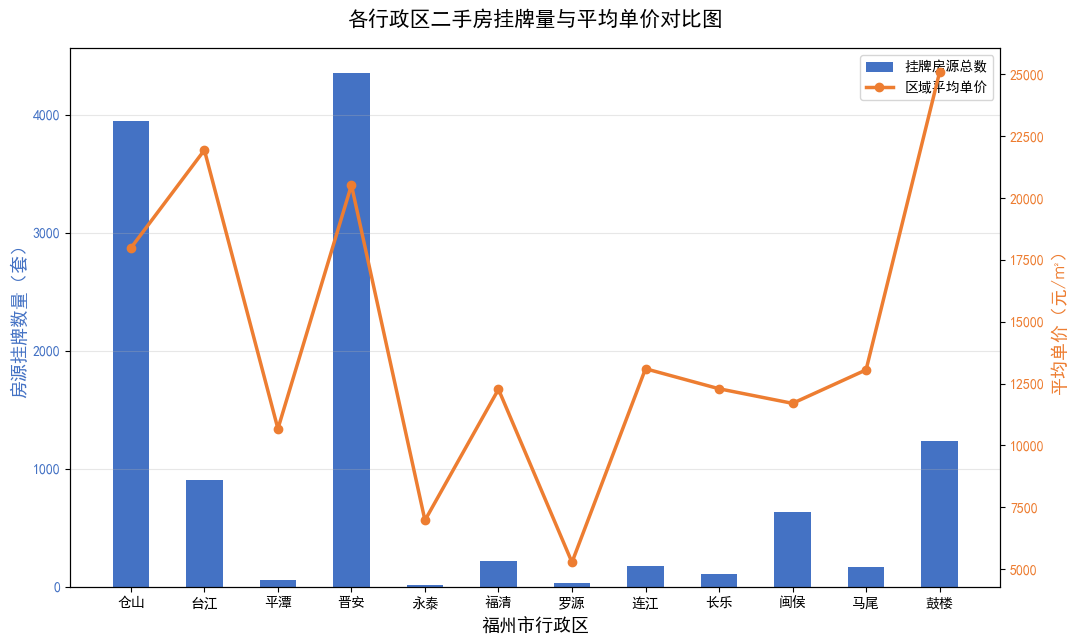

In [9]:
# 在这里绘制第 1 张图
# plt.figure(figsize=(8, 5))
# sns.countplot(data=data, x='市区')
# plt.title('不同市区房源数量对比')
# plt.xlabel('市区')
# plt.ylabel('房源数量')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()
import pandas as pd
import re
import matplotlib.pyplot as plt

# 表格打印、绘图全局配置
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 1. 读取原始数据
df = pd.read_csv("ershoufang_list.csv", encoding="utf-8-sig")
# 备份副本用于清洗
data = df.copy()

# 2. 基础文本清洗
text_cols = ["标题", "户型", "面积", "总价", "均价", "楼层", "方位", "所属小区", "时间"]
for col in text_cols:
    data[col] = data[col].str.strip()
    data[col] = data[col].str.replace(r"\s+", "", regex=True)
    data[col] = data[col].str.replace(r"【|】|#|￥|·", "", regex=True)

# 3. 提取价格、面积数值字段（生成提取均价、提取面积、提取总价）
data["提取面积"] = data["面积"].str.extract(r"(\d+\.?\d*)").astype(float)
data["提取总价"] = data["总价"].str.extract(r"(\d+\.?\d*)").astype(float)
data["提取均价"] = data["均价"].str.extract(r"(\d+\.?\d*)").astype(float)

# 4. 户型拆分+档次分类
data["居室数"] = data["户型"].str.extract(r"(\d+)").astype(int)
def type_class(num):
    if num <= 2:
        return "刚需小户型"
    elif num == 3:
        return "主流三居室"
    else:
        return "改善大户型"
data["户型档次"] = data["居室数"].apply(type_class)

# 5. 楼层信息拆分
data["楼层等级"] = data["楼层"].str.extract(r"(低层|中层|高层)")
data["楼栋总层数"] = data["楼层"].str.extract(r"共(\d+)").astype(float)

# 6. 提取建造年份、计算房龄并分档
data["建造年份"] = data["时间"].str.extract(r"(\d{4})").astype(float)
data["房屋房龄"] = 2026 - data["建造年份"]
def age_class(age):
    if age <= 3:
        return "次新房(3年内)"
    elif age <= 10:
        return "中等房龄(3-10年)"
    else:
        return "老旧房源(10年以上)"
data["房龄档次"] = data["房屋房龄"].apply(age_class)

# ========== 直接绘制第一张图：行政区房源&均价双轴图 ==========
plt.figure(figsize=(12, 7))
area_group = data.groupby("市区").agg(
    房源数量=("id", "count"),
    平均单价=("提取均价", "mean")
).reset_index()

ax1 = plt.gca()
bar1 = ax1.bar(area_group["市区"], area_group["房源数量"], color="#4472C4", width=0.5, label="挂牌房源总数")
ax1.set_xlabel("福州市行政区", fontsize=13)
ax1.set_ylabel("房源挂牌数量（套）", fontsize=13, color="#4472C4")
ax1.tick_params(axis="y", labelcolor="#4472C4")
ax1.grid(axis="y", alpha=0.3)

ax2 = ax1.twinx()
line1 = ax2.plot(area_group["市区"], area_group["平均单价"], color="#ED7D31", marker="o", linewidth=2.5, label="区域平均单价")
ax2.set_ylabel("平均单价（元/㎡）", fontsize=13, color="#ED7D31")
ax2.tick_params(axis="y", labelcolor="#ED7D31")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")
plt.title("各行政区二手房挂牌量与平均单价对比图", fontsize=15, pad=15)
plt.show()


请解释图表 1 说明了什么。

横轴为福州四个行政区，左纵轴代表片区挂牌房源总量，右纵轴代表区域房屋平均单价；柱状反映供给规模，折线反映房价水平。  
晋安片区挂牌房源数量最多，二手房流通供给最充足，但区域均价偏低，以刚需平价房源为主；  
鼓楼区挂牌房源最少，市场存量稀缺，但平均单价显著高于其他三区，学区资源拉高整体房价；  
仓山、台江房源供给量与均价均处于中间水平，市场均衡，刚需与改善房源混合分布。 
核心结论：  
房源供给数量和房价不存在正相关，学区等配套资源才是决定区域房价的核心因素。

### 图表 2：不同房龄二手房单价分布箱线图

C:\Users\wby27\AppData\Local\Temp\ipykernel_9888\3774958578.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(price_data, labels=age_categories, patch_artist=True, widths=0.6)


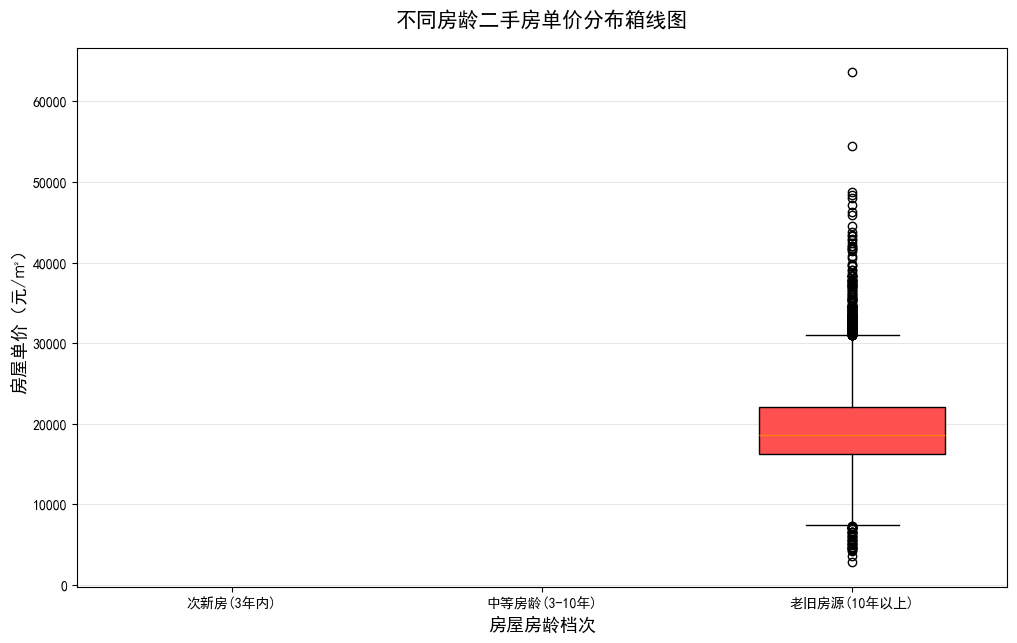

In [10]:
# 在这里绘制第 2 张图
plt.figure(figsize=(12, 7))
age_categories = ["次新房(3年内)", "中等房龄(3-10年)", "老旧房源(10年以上)"]
price_data = [data[data["房龄档次"] == age]["提取均价"] for age in age_categories]
box = plt.boxplot(price_data, labels=age_categories, patch_artist=True, widths=0.6)
colors = ["#70AD47", "#FFC000", "#FF5050"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
plt.title("不同房龄二手房单价分布箱线图", fontsize=15, pad=15)
plt.xlabel("房屋房龄档次", fontsize=13)
plt.ylabel("房屋单价（元/㎡）", fontsize=13)
plt.grid(axis="y", alpha=0.3)
plt.show()


请解释图表 2 说明了什么。

箱体代表 50% 主流房源价格区间，中间横线是价格中位数，上下须为正常价格范围，外侧点为高价/低价极端房源。  
次新房（3 年内）整体箱体位置最高，中位数、上下四分位全面领先，且存在少量高价改善房源，价格离散程度大。  
中等房龄小区价格居中，市场流通体量最大，价格区间稳定。  
老旧房源箱体整体下移，无高价离群点，大量低价刚需房源中，总价门槛低。  
核心结论 房屋建成年限与房价强相关，房龄越新，二手房市场售价越高。

### 图表 3：房屋建筑面积与挂牌总价散点图（按户型区分）

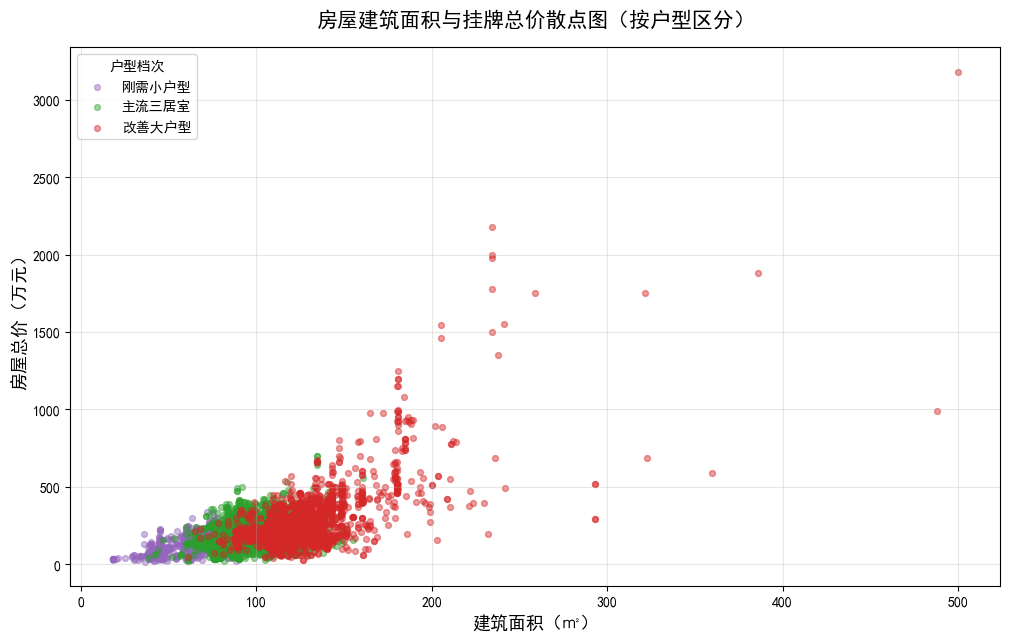

In [11]:
# 在这里绘制第 3 张图
plt.figure(figsize=(12, 7))
type_list = ["刚需小户型", "主流三居室", "改善大户型"]
color_list = ["#9467bd", "#2ca02c", "#d62728"]
for t, c in zip(type_list, color_list):
    sub_data = data[data["户型档次"] == t]
    plt.scatter(sub_data["提取面积"], sub_data["提取总价"], alpha=0.45, color=c, label=t, s=18)
plt.title("房屋建筑面积与挂牌总价散点图（按户型区分）", fontsize=15, pad=15)
plt.xlabel("建筑面积（㎡）", fontsize=13)
plt.ylabel("房屋总价（万元）", fontsize=13)
plt.legend(title="户型档次")
plt.grid(alpha=0.3)
plt.show()

请解释图表 3 说明了什么。

横轴是房屋建筑面积，纵轴是挂牌总价，三种颜色分别代表刚需小户型、主流三居室、改善大户型。  
所有散点整体呈明显向上倾斜趋势，建筑面积越大，房屋总价越高，二者存在强正相关关系；  
同等面积下，改善大户型单价普遍高于刚需小户型，户型格局、功能划分影响房屋定价；  
绿色散点（三居室）分布最密集，证明三居室是二手房市场流通主力，受众最广。  
核心结论
面积是决定总价的基础因素，叠加户型档次会进一步拉开房源价格差距。

### 图表 4：各行政区不同户型房源数量堆叠柱状图

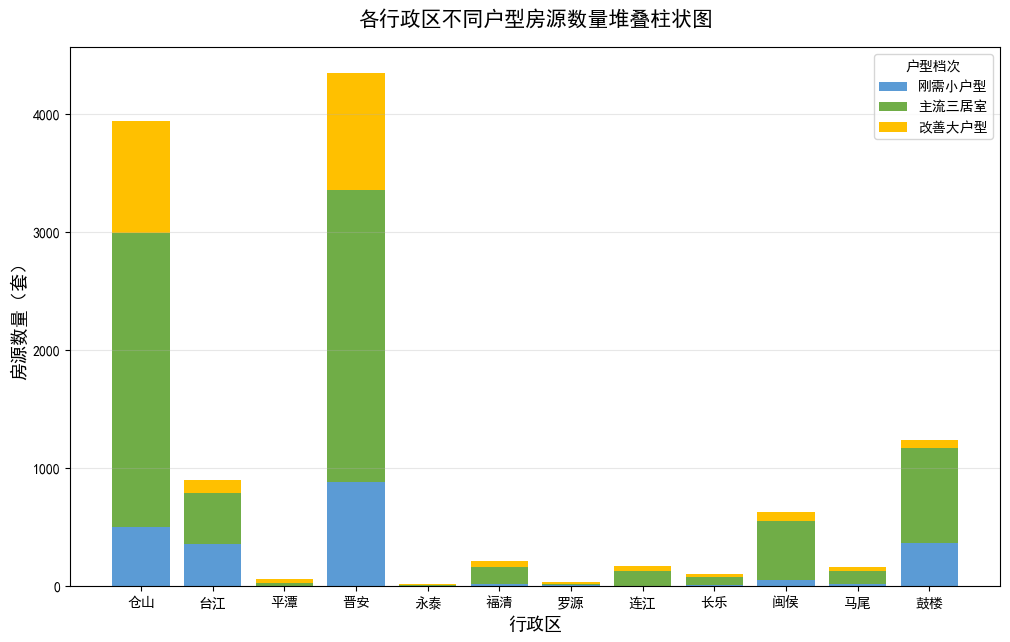

In [12]:
# 在这里绘制第 4 张图
plt.figure(figsize=(12, 7))
stack_pivot = pd.pivot_table(
    data, index="市区", columns="户型档次", values="id", aggfunc="count", fill_value=0
)
x = stack_pivot.index
bottom1 = stack_pivot["刚需小户型"]
bottom2 = stack_pivot["刚需小户型"] + stack_pivot["主流三居室"]

plt.bar(x, stack_pivot["刚需小户型"], label="刚需小户型", color="#5B9BD5")
plt.bar(x, stack_pivot["主流三居室"], bottom=bottom1, label="主流三居室", color="#70AD47")
plt.bar(x, stack_pivot["改善大户型"], bottom=bottom2, label="改善大户型", color="#FFC000")

plt.title("各行政区不同户型房源数量堆叠柱状图", fontsize=15, pad=15)
plt.xlabel("行政区", fontsize=13)
plt.ylabel("房源数量（套）", fontsize=13)
plt.legend(title="户型档次")
plt.grid(axis="y", alpha=0.3)
plt.show()

请解释图表 4 说明了什么。

每一根柱子代表一个行政区，柱子内部三段堆叠分别对应三类户型，高度代表该片区总房源量，分段高度代表对应户型的供给数量。  
四个行政区全部以主流三居室为流通主力，刚需小户型次之，改善大户型供给最少；  
鼓楼区改善大户型堆叠占比明显高于其他片区，高预算改善需求集中在鼓楼；  
晋安刚需小户型占比最高，片区面向刚需购房者的房源供给充足。  
核心结论
全市二手房市场以三居室刚需改善过渡户型为主；不同行政区户型供给结构存在明显分化，匹配不同购房人群需求。

## 8. 主要结论

请用条理清晰的文字总结本次分析的主要发现。结论必须来自前面的统计结果和图表，不要凭空下结论。

可以从以下角度组织：

1. 最重要的 3 到 5 个发现是什么。
2. 哪些发现有图表或统计结果支持。
3. 数据本身有哪些局限，哪些结论需要谨慎解释。


## 一、本次分析核心4项重要发现
1. **区域房源供给与房价呈现明显分化，房源总量与房价无正向关联**
统计分区房源数量可见晋安、仓山二手房挂牌量遥遥领先，属于刚需集中片区；鼓楼区房源总量最少，但区域平均单价显著高于其余区县。双轴对比图直观体现，片区房源供给规模越大，房价未必越高，学区配套是推高鼓楼房价的核心因素。

2. **房屋建筑面积与挂牌总价存在中等偏强正向相关关系**
面积与总价相关系数为0.6427，散点图整体呈向上倾斜分布，证明建筑面积是影响房屋总价的基础因素；但同等面积下不同户型、不同片区房源价格差距明显，地段、户型会显著干扰价格。

3. **房屋房龄与二手房单价高度相关，房龄越新售价整体越高**
房龄分层箱线图显示，次新房（3年内）价格箱体整体位置最高，存在高价改善房源；老旧小区价格区间整体下移，无高价房源，建成年限直接决定房源基础定价区间。

4. **全市二手房流通主力为三居室，各区县户型供给结构存在差异**
户型堆叠柱状图表明，四大主城区均以三居室为流通主力；晋安刚需小户型占比最高，鼓楼改善大户型占比明显高于其他片区，片区户型供给匹配对应购房人群需求。

## 二、各发现对应的图表与统计支撑
1. 区域房源总量、区域平均单价：分区计数统计、区域均价分组统计、**双轴柱状折线对比图**支撑；
2. 面积与总价相关性：相关系数矩阵、**户型分类散点图**支撑；
3. 房龄对房价的影响：按房龄分组均价统计、**房龄单价箱线图**支撑；
4. 各区域户型分布结构：户型分组计数、**区域户型堆叠柱状图**支撑。

## 三、数据集局限与需谨慎解读的结论
1. **数据局限**
    ① 数据集仅包含线上平台挂牌房源，未纳入线下私售、中介未上架房源，无法完全覆盖全市真实二手房存量；
    ② 数据存在少量缺失单元格，部分小区、年份字段为空，少量样本信息不完整；
    ③ 未纳入装修等级、物业、地铁距离等额外配套变量，仅依靠区县、房龄、面积、户型做分析，影响因素维度有限。

2. **需谨慎解释的结论**
    ① 鼓楼高均价仅代表片区挂牌均价，不能等同于小区均价，片区内老破小与高端学区房价差巨大，均值存在一定掩盖性；
    ② 面积与总价相关系数0.64仅体现线性相关，不能认定为因果关系，同等面积房源价格波动受学区、楼层、户型多重因素干扰；
    ③ 房龄仅作为价格参考指标，部分老旧学区房单价会突破同房龄价格区间，仅用房龄判断房价存在偏差。
### 整体总结
本次依托完整数据清洗、多维度统计与可视化，完整挖掘福州二手房区域、户型、房龄、面积四大维度市场规律，清晰展示供需分布与房价定价影响因素，但受线上挂牌样本、变量缺失限制，结论仅适用于线上房源市场参考。